---
title: Machine Learning
authors:
  - name: Christoph Würsch
    affiliation: ZHAW School of Engineering
  - name: Jorge Peña Queralta
    affiliation: ZHAW School of Engineering
exports:
- format: pdf
  template: https://github.com/marbetschar/plain_latex_article/archive/refs/heads/main.zip
  output: Machine-Learning.pdf
  id: machine-learning-pdf
downloads:
  - id: machine-learning-pdf
    title: Download as PDF
---

# Machine Learning

```{admonition} Philosophy: Theory & Practice
:class: tip
- **Theory**: Understand the foundations of machine learning concepts
- **Practical**: Focus on practical techniques and state-of-the-art software tools
- **State of the Art**: From ML classics to modern methods
- **Hands-on**: Exercises provide fun, practical experience
```

## Summary and Key Takeaways

### Core Principles

1. **Generalization**: The ultimate goal is to create models that perform well on unseen data, not just the training data.

2. **Bias-Variance Tradeoff**: Every model makes a tradeoff between underfitting (high bias) and overfitting (high variance).

3. **No Free Lunch**: No single algorithm works best for all problems. Choose based on your data and problem characteristics.

4. **Feature Engineering**: The quality of your features often matters more than the choice of algorithm.

5. **Evaluation**: Always use proper evaluation techniques (train-test split, cross-validation) to assess model performance.

### Practical Skills Acquired

- Data preprocessing and cleaning
- Exploratory data analysis and visualization
- Feature engineering and selection
- Model selection and hyperparameter tuning
- Supervised learning (classification and regression)
- Unsupervised learning (clustering, dimensionality reduction)
- Neural networks and deep learning
- Model evaluation and interpretation
- Python programming with ML libraries (numpy, pandas, scikit-learn, tensorflow/keras)

### Python Libraries Used

| Library | Purpose | Key Functions/Classes |
|---------|---------|------------------------|
| **numpy** | Numerical computing | array, linspace, random, etc. |
| **pandas** | Data manipulation | DataFrame, Series, read_csv, etc. |
| **matplotlib** | Visualization | pyplot, figure, scatter, plot, etc. |
| **seaborn** | Statistical visualization | heatmap, boxplot, pairplot, etc. |
| **scikit-learn** | Machine learning | All ML algorithms, preprocessing, metrics |
| **tensorflow/keras** | Deep learning | Sequential, Dense, Conv2D, etc. |
| **librosa** | Audio processing | load, stft, mfcc, etc. |

```{admonition} Best Practices
:class: important
1. **Start Simple**: Begin with simple models and baseline approaches
2. **Visualize Everything**: Plot your data, model predictions, and errors
3. **Validate Properly**: Always use proper train-test splits and cross-validation
4. **Preprocess Carefully**: Scale features, handle missing values, encode categories
5. **Iterate**: Model development is an iterative process of experimentation
6. **Document**: Keep track of what you tried and what worked
7. **Stay Curious**: Machine learning is a rapidly evolving field - keep learning!
```

## Quick Reference

### Common Preprocessing Steps

In [23]:
# 1. Load data
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils._repr_html import estimator
from zmq.backend import backend

df = pd.read_csv('machine-learning/DiabetesDataset.csv')

# 2. Handle missing values
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean())  # Numerical
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].mode())  # Categorical
df.dropna(inplace=True) # Simply drop rows with missing values

# 3. Encode categorical variables
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False)
X_encoded = encoder.fit_transform(df[['Diabetes']])

# 4. Scale numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.select_dtypes(include=['float64', 'int64']))
y = df['Diabetes']

# 5. Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Common Hyperparameter Tuning

In [24]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

# Grid Search
param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}
grid_search = GridSearchCV(estimator, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_:.4f}")

# Random Search
param_dist = {'n_estimators': randint(50, 200), 'max_depth': [None] + list(randint(5, 50).rvs(10)), 'min_samples_split': randint(2, 20)}
random_search = RandomizedSearchCV(estimator, param_dist, n_iter=20, cv=5)
random_search.fit(X_train, y_train)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best score: 1.0000


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, np.int64(48), ...], 'min_samples_split': <scipy.stats....t 0x111b5bda0>, 'n_estimators': <scipy.stats....t 0x110dcc3b0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_exa

### Common Model Evaluation

In [28]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

estimator = RandomForestClassifier(min_samples_split=2, n_estimators=50, max_depth=None, random_state=42)
estimator.fit(X_train, y_train)
y_pred = estimator.predict(X_test)

# Classification metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1: {f1_score(y_test, y_pred):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

# Regression metrics
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1: 1.0000
Confusion Matrix:
[[99  0]
 [ 0 55]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00        55

    accuracy                           1.00       154
   macro avg       1.00      1.00      1.00       154
weighted avg       1.00      1.00      1.00       154

MSE: 0.0000
MAE: 0.0000
R²: 1.0000


## Introduction to Machine Learning

### Educational Objectives

- Basic, high-level understanding of what machine learning is
- Understand the three main ML paradigms with examples
- Data preparation and visualization techniques
- Identify different data types and their characteristics
- Perform data consolidation, preprocessing, and cleaning
- Create effective data visualizations

### Key Concepts

#### ML Paradigms

````{grid} 3
:gutter: 2

```{grid-item-card} Supervised Learning
**Data**: $(x, y)$ where $x$ is input, $y$ is label
**Goal**: Learn function to map $x \rightarrow y$
**Example**: Classifying apples vs. oranges
```

```{grid-item-card} Unsupervised Learning
**Data**: $x$ (no labels)
**Goal**: Learn underlying structure in data
**Example**: Grouping similar items together
```

```{grid-item-card} Reinforcement Learning
**Data**: State-action pairs
**Goal**: Maximize future rewards over time
**Example**: Learning to navigate an environment
```
````

#### Data Types

| Type | Description | Example |
|------|-------------|---------|
| Numerical | Continuous or discrete numbers | Age, temperature |
| Categorical | Finite set of categories | Color, gender |
| Ordinal | Categories with order | Rating (1-5 stars) |
| Text | Natural language | Product reviews |
| Image | Pixel arrays | Photographs |
| Audio | Sound waveforms | Speech recordings |

#### Data Preprocessing Pipeline

```{mermaid}
graph LR
    A[Raw Data] --> B[Data Cleaning]
    B --> C[Feature Engineering]
    C --> D[Data Transformation]
    D --> E[Train-Test Split]
    E --> F[Model Training]
    F --> G[Evaluation]
```

### Practical Example: Data Visualization

```{note}
Always visualize your data before modeling to understand distributions, relationships, and potential issues like outliers or missing values.
```

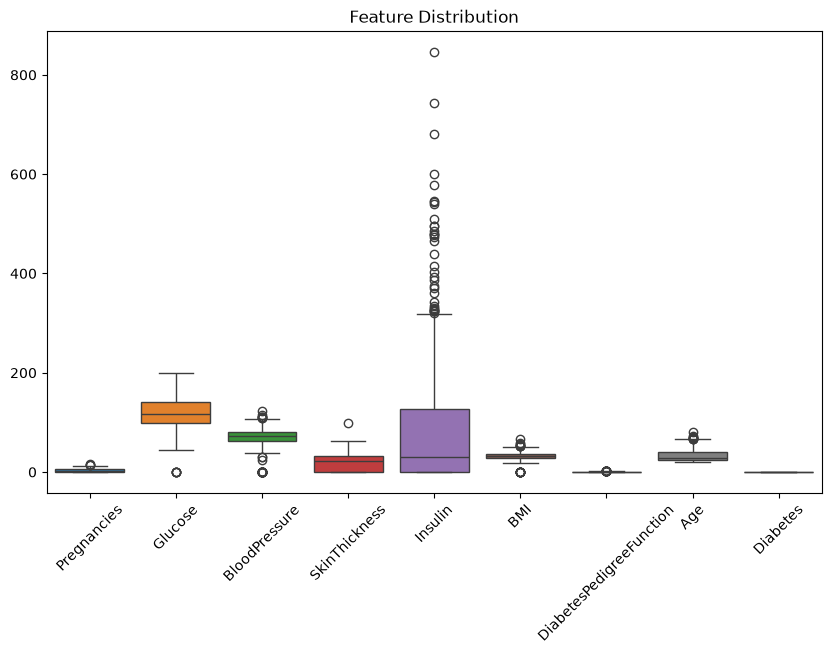

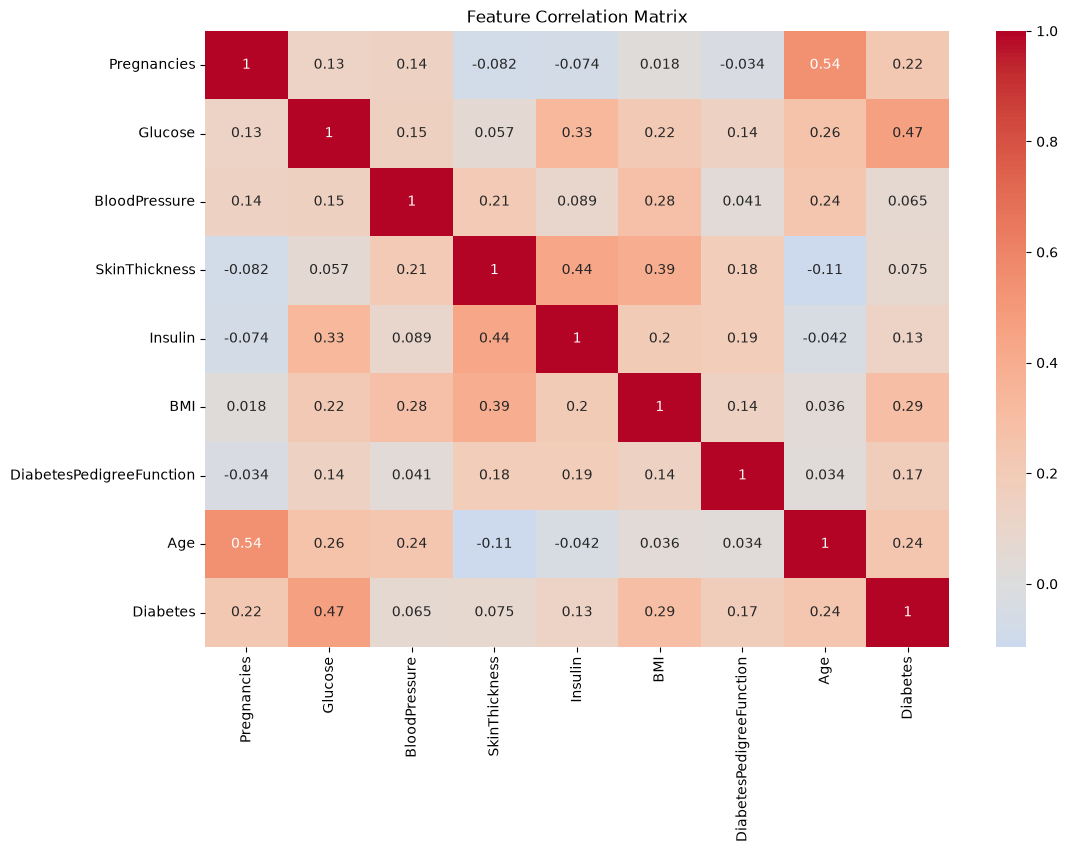

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data = pd.read_csv('machine-learning/DiabetesDataset.csv')

# Basic visualization
plt.figure(figsize=(10, 6))
sns.boxplot(data=data.select_dtypes(include=['float64', 'int64']))
plt.title('Feature Distribution')
plt.xticks(rotation=45)
plt.show()

# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

## Supervised Learning & k-Nearest Neighbors

### Educational Objectives

- Address supervised ML problems: outline approach and name main concepts
- Understand and explain the kNN algorithm and its advantages/disadvantages
- Remember and explain most frequently used distance measures
- Remember and explain prevalent performance measures for ML evaluation

### Key Concepts

#### k-Nearest Neighbors Algorithm

kNN is a simple, instance-based learning algorithm:

1. **Store** all training data
2. **Calculate** distance between new point and all training points
3. **Find** k nearest neighbors
4. **Predict** based on majority vote (classification) or average (regression)

```{math}
\text{Distance metrics:}\\
\text{Euclidean: } d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}\\
\text{Manhattan: } d(x, y) = \sum_{i=1}^{n} |x_i - y_i|\\
\text{Minkowski: } d(x, y) = \left(\sum_{i=1}^{n} |x_i - y_i|^p\right)^{1/p}
```

#### Choosing k

- **Small k**: More flexible, can overfit, sensitive to noise
- **Large k**: More stable, can underfit, smoother decision boundaries
- **Optimal k**: Found via cross-validation

#### Distance Measures

| Measure | Formula                             | When to Use      |
|---------|-------------------------------------|------------------|
| Euclidean | $\sqrt{\sum (x_i - y_i)^2}$         | General purpose  |
| Manhattan | $\sum \| x_i - y_i\|$               | High-dimensional data |
| Cosine | $1 - \frac{x \cdot y}{\|x\| \|y\|}$ | Text data        |
| Hamming | Count of differing positions        | Categorical data |

#### Performance Measures

````{grid} 2
:gutter: 2

```{grid-item-card} Classification Metrics
- **Accuracy**: $\frac{TP + TN}{TP + TN + FP + FN}$
- **Precision**: $\frac{TP}{TP + FP}$ (How many selected are correct?)
- **Recall**: $\frac{TP}{TP + FN}$ (How many actual positives found?)
- **F1 Score**: $2 \times \frac{Precision \times Recall}{Precision + Recall}$
- **Confusion Matrix**: Visualizes TP, TN, FP, FN
```

```{grid-item-card} Regression Metrics
- **MSE**: Mean Squared Error - sensitive to outliers
- **RMSE**: Root Mean Squared Error - same units as target
- **MAE**: Mean Absolute Error - robust to outliers
- **R²**: Coefficient of determination - explains variance
```
````

In [1]:
import numpy as np

# rows := actual, cols := predicted
confusion_matrix = np.array([
    [12, 6, 9],   # Actual Yellow Car
    [8, 14, 2],   # Actual Green Car
    [3, 1, 7]     # Actual Blue Car
])

tp = confusion_matrix[1, 1]
fp = confusion_matrix[:, 1].sum() - tp
fn = confusion_matrix[1, :].sum() - tp
tn = confusion_matrix.sum() - (tp + fp + fn)

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy: {tp + tn / (tp + tn + fp + fn):.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")

Accuracy: 14.5000
Precision: 0.6667
Recall: 0.5833
F1: 0.6222


### Practical Example: kNN Implementation

```{warning}
Always scale your features when using distance-based algorithms like kNN, SVM, or neural networks. Use StandardScaler for normally distributed data and MinMaxScaler for bounded ranges.
```

In [35]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Load and prepare data
df = pd.read_csv('machine-learning/DiabetesDataset.csv')
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for distance-based algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train kNN classifier
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred = knn.predict(X_test_scaled)

# Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Find optimal k using cross-validation
from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors': range(1, 21)}
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)
print(f"Best k: {grid_search.best_params_['n_neighbors']}")

Accuracy: 0.6948
              precision    recall  f1-score   support

           0       0.75      0.80      0.77        99
           1       0.58      0.51      0.54        55

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.66       154
weighted avg       0.69      0.69      0.69       154

Best k: 11


## Model Selection, Bias-Variance Tradeoff & Regularization

### Educational Objectives

- Understand the No Free Lunch theorem and Ockham's Razor
- Explain the influence of bias and variance on model performance
- Explain loss minimization with stochastic gradient descent (SGD)
- Use sound experimental setup to select model parameters, evaluate models, and choose among models

### Key Concepts

#### Bias-Variance Tradeoff

```{mermaid}
graph LR
    A[High Bias<br>Underfitting] -- Increase Complexity<br>of Model --> B[Optimal Model]
    B -- Increase Complexity<br> even Further --> C[High Variance<br>Overfitting]
```

```{math}
\text{Generalization Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}
```

```{prf:theorem} No Free Lunch Theorem
:class: important
There is no single machine learning algorithm that works best for all problems. The performance of any algorithm depends on the specific dataset and problem characteristics.
```

```{prf:axiom} Ockham's Razor
:class: note
When two models have similar performance, prefer the simpler one. Simplicity is a virtue in machine learning.
```

#### Regularization Techniques

| Technique | Formula              | Effect |
|-----------|----------------------|--------|
| **Lasso (L1)** | $\lambda \sum \|w_i  \|$ | Feature selection, sparse weights |
| **Ridge (L2)** | $\lambda \sum w_i^2$ | Prevents large weights |
| **Elastic Net** | $\lambda_1 \sum      \|w_i\| + \lambda_2 \sum w_i^2$ | Combines L1 and L2 |

## Model Selection, Bias-Variance Tradeoff & Regularization

### Educational Objectives

- Understand the No Free Lunch theorem and Ockham's Razor
- Explain the influence of bias and variance on model performance
- Explain loss minimization with stochastic gradient descent (SGD)
- Use sound experimental setup to select model parameters, evaluate models, and choose among models

### Key Concepts

#### Bias-Variance Tradeoff

```{mermaid}
graph LR
    A[High Bias<br>Underfitting] -- Increase Complexity<br>of Model --> B[Optimal Model]
    B -- Increase Complexity<br> even Further --> C[High Variance<br>Overfitting]
```

```{math}
\text{Generalization Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}
```

```{prf:theorem} No Free Lunch Theorem
:class: important
There is no single machine learning algorithm that works best for all problems. The performance of any algorithm depends on the specific dataset and problem characteristics.
```

```{prf:axiom} Ockham's Razor
:class: note
When two models have similar performance, prefer the simpler one. Simplicity is a virtue in machine learning.
```

#### Regularization Techniques

| Technique | Formula              | Effect |
|-----------|----------------------|--------|
| **Lasso (L1)** | $\lambda \sum \|w_i  \|$ | Feature selection, sparse weights |
| **Ridge (L2)** | $\lambda \sum w_i^2$ | Prevents large weights |
| **Elastic Net** | $\lambda_1 \sum      \|w_i\| + \lambda_2 \sum w_i^2$ | Combines L1 and L2 |



#### Model Evaluation

In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('machine-learning/DiabetesDataset.csv')
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

estimator = RandomForestClassifier(random_state=42)



##### Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

##### K-Fold Cross-Validation

In [10]:
from sklearn.model_selection import cross_val_score, KFold


kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(estimator, X, y, cv=kfold, scoring='accuracy')
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Mean CV Accuracy: 0.7643 (+/- 0.0488)


##### Learning Curves

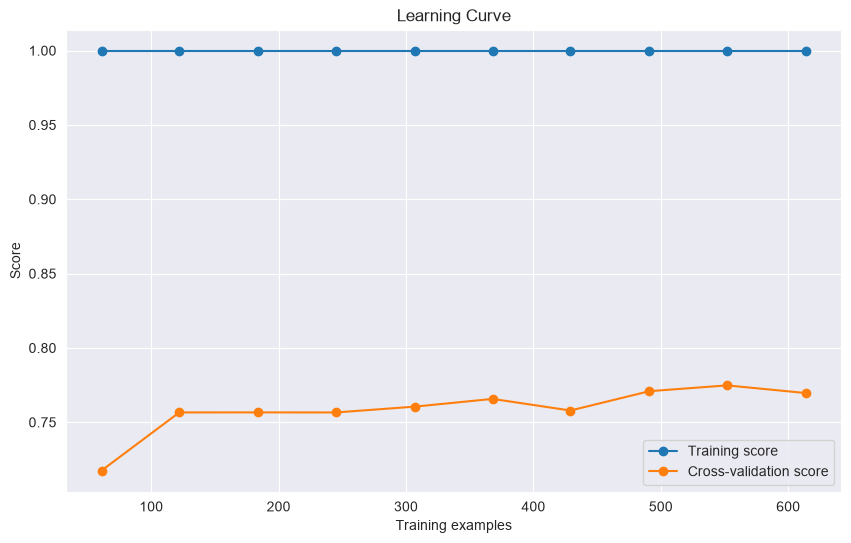

In [13]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)
)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(1), 'o-', label='Training score')
plt.plot(train_sizes, test_scores.mean(1), 'o-', label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('Score')
plt.legend()
plt.title('Learning Curve')
plt.show()

#### Stochastic Gradient Descent (SGD)

```{math}
\text{Update rule: } w_{t+1} = w_t - \eta \nabla L(w_t)
```

- $\eta :=$ learning rate
- $\nabla L(w_t) :=$ gradient of loss function at $w_t$

In [15]:
from sklearn.linear_model import SGDClassifier, SGDRegressor
sgd_clf = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.0001, max_iter=1000, random_state=42)
sgd_reg = SGDRegressor(penalty='l2', alpha=0.0001, max_iter=1000, random_state=42)

## Feature Engineering

### Educational Objectives

- Use EDA, data preparation, and cleaning as necessary steps before ML projects
- Generate features using transformations (binning, interaction features)
- Explain four approaches for feature selection
- Generate features from text data (BoW, tf-idf, n-grams)
- Identify important features for audio data: STFT and MFCC

### Key Concepts

#### Feature Engineering Pipeline

```{mermaid}
graph LR
    A[Raw Data] --> B[Data Cleaning]
    B --> C[Feature Generation]
    C --> D[Feature Selection]
    D --> E[Feature Transformation]
    E --> F[Model Input]
```

#### Data Cleaning

<Axes: title={'center': 'After'}, ylabel='Insulin'>

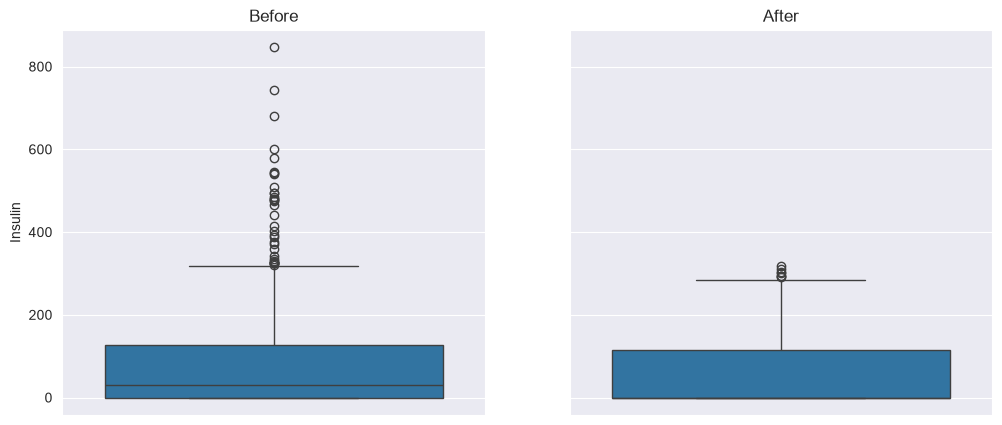

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('machine-learning/DiabetesDataset.csv')

# Handle missing values
df.dropna(inplace=True)

# Handle outliers using IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
ax1.set_title('Before')
ax2.set_title('After')

sns.boxplot(data=df['Insulin'], ax=ax1)
df = remove_outliers(df, 'Insulin')
sns.boxplot(data=df["Insulin"], ax=ax2)

#### Feature Generation Techniques

````{grid} 2
:gutter: 2

```{grid-item-card} Numerical Features
- **Binning**: Convert continuous to categorical
- **Polynomial**: $x, x^2, x^3$ for non-linear relationships
- **Interaction**: $x_1 \times x_2$ for feature combinations
- **Log Transform**: $\log(x)$ for skewed distributions
- **Scaling**: Standardize or normalize features
```

```{grid-item-card} Categorical Features
- **One-Hot Encoding**: Create binary columns for each category
- **Label Encoding**: Convert categories to integers
- **Target Encoding**: Replace categories with target mean
- **Frequency Encoding**: Replace with frequency of category
```
````

In [24]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, PolynomialFeatures

# Load data
X = pd.read_csv('machine-learning/DiabetesDataset.csv')

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Min-max scaling
minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X)

# Robust scaling
robust = RobustScaler()
X_robust = robust.fit_transform(X)

# One-hot encoding
encoder = OneHotEncoder(drop='first', sparse_output=False)
X_encoded = encoder.fit_transform(X)

# Polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

#### Text Feature Extraction

````{grid} 2
:gutter: 2

```{grid-item-card} Bag of Words (BoW)
- Counts word occurrences
- Ignores grammar and word order
- Simple and effective baseline
```

```{grid-item-card} TF-IDF
- Term Frequency-Inverse Document Frequency
- Weights words by importance
- Rare words get higher weights
```
````

In [26]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

texts = np.array([
    'The sun is shining',
    'The weather is sweet',
    'The sun is shining and the weather is sweet'
])

# Bag of Words
bow = CountVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2))
X_bow = bow.fit_transform(texts)

# TF-IDF
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(texts)

#### Audio Feature Extraction

````{grid} 2
:gutter: 2

```{grid-item-card} STFT (Short-Time Fourier Transform)
- Converts audio to time-frequency representation
- Captures frequency content over time
- Useful for speech and music analysis
```

```{grid-item-card} MFCC (Mel-Frequency Cepstral Coefficients)
- Represents spectral envelope of sound
- Mimics human auditory system
- State-of-the-art for speech recognition
```
````

In [37]:
import librosa

# Load audio file
y, sr = librosa.load('machine-learning/0_george_1.wav', sr=22050)

# Extract STFT
stft = librosa.stft(y, n_fft=2048, hop_length=512)
stft_magnitude = np.abs(stft)

# Extract MFCC
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
mfcc_mean = np.mean(mfccs, axis=1)
mfcc_std = np.std(mfccs, axis=1)

ImportError: Numba needs NumPy 2.4 or less. Got NumPy 2.5.

#### Feature Selection Methods

| Method | Description | When to Use |
|--------|-------------|-------------|
| **Variance Threshold** | Remove features with low variance | Initial filtering |
| **Univariate Selection** | Select best features based on statistical tests | Quick feature reduction |
| **RFE** | Remove features iteratively based on model weights | Model-based selection |
| **Model-based Ranking** | Use feature importance from models | Tree-based models |

In [6]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import VarianceThreshold, SelectKBest, RFE, f_classif

df = pd.read_csv('machine-learning/DiabetesDataset.csv')
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

# Variance threshold
selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X)

# Select top k features
selector = SelectKBest(score_func=f_classif, k=3)
X_selected = selector.fit_transform(X, y)

# Recursive Feature Elimination
estimator = LogisticRegression(max_iter=1000)
selector = RFE(estimator, n_features_to_select=5)
X_selected = selector.fit_transform(X, y)

## Linear Models & Logistic Regression

### Educational Objectives

- Understand probability theory fundamentals (random variables, distributions)
- Design loss functions using maximum likelihood and negative log-likelihood
- Implement logistic regression for binary classification
- Understand neuron structure and activation functions

### Key Concepts

#### Probability Theory Basics

```{math}
E[X] = \sum x P(X = x) \text{ (discrete)}, \quad \int x f_X(x) dx \text{ (continuous)}\
Var(X) = E[(X - E[X])^2] = E[X^2] - E[X]^2
```

````{grid} 2
:gutter: 2

```{grid-item-card} Bayes' Theorem
$$P(A|B) = \frac{P(B|A) P(A)}{P(B)}$$

Fundamental for Bayesian approaches to ML
```

```{grid-item-card} Common Distributions
- **Bernoulli**: Binary outcomes (p)
- **Gaussian**: Continuous, symmetric (μ, σ²)
- **Multinomial**: Multiple categories
- **Poisson**: Count data (λ)
```
````

#### Loss Function Design

##### Maximum Likelihood Estimation (MLE)

```{math}
L(\theta) = P(X | \theta) = \prod_{i=1}^n P(x_i | \theta)\
\ell(\theta) = \sum_{i=1}^n \log P(x_i | \theta)\
\hat{\theta} = \arg\max_{\theta} \ell(\theta)
```

##### Negative Log-Likelihood (NLL)

```{math}
\text{NLL} = -\ell(\theta) = -\sum_{i=1}^n \log P(x_i | \theta)
```

#### Logistic Regression

##### Sigmoid Function

```{math}
\sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = w_0 + w_1 x_1 + \dots + w_d x_d
```

##### Binary Cross-Entropy Loss

```{math}
\text{BCE} = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]
```

##### Implementation

In [9]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

df = pd.read_csv('machine-learning/DiabetesDataset.csv')
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Basic logistic regression
model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Logistic regression with cross-validated regularization
model_cv = LogisticRegressionCV(Cs=[0.001, 0.01, 0.1, 1, 10, 100], cv=5, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
model_cv.fit(X_train, y_train)

# Get coefficients
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]}).sort_values('Coefficient', ascending=False)

# Predictions and evaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
confusion_matrix(y_test, y_pred)

Accuracy: 0.7468
Precision: 0.6379
Recall: 0.6727
F1 Score: 0.6549


/Users/marbetschar/Development/marbetschar/marco.betschart.name/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/marbetschar/Development/marbetschar/marco.betschart.name/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/marbetschar/Development/marbetschar/marco

array([[78, 21],
       [18, 37]])

## Neural Networks & Deep Learning

### Educational Objectives

- Understand neural network architectures (shallow and deep)
- Explain activation functions (ReLU, sigmoid, softmax)
- Understand loss functions (MSE, cross-entropy)
- Implement training with gradient descent and backpropagation
- Apply optimization techniques (momentum, adaptive learning rates)
- Implement CNNs for image processing
- Apply regularization (L1/L2, dropout) and hyperparameter tuning

### Key Concepts

#### Neural Network Architecture

```{mermaid}
graph LR
    A[Input Layer] --> B[Hidden Layer 1]
    B --> C[Hidden Layer 2]
    C --> D[...]
    D --> E[Output Layer]
```

#### Activation Functions

````{grid} 3
:gutter: 1

```{grid-item-card} ReLU
**Function**: $f(x) = \max(0, x)$
**Pros**: Solves vanishing gradient, computationally efficient
**Cons**: Dies for negative inputs
```

```{grid-item-card} Sigmoid
**Function**: $f(x) = \frac{1}{1 + e^{-x}}$
**Pros**: Outputs between 0 and 1
**Cons**: Vanishing gradients
```

```{grid-item-card} Softmax
**Function**: $f(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$
**Use**: Multi-class classification output
**Property**: Outputs sum to 1
```
````

#### Loss Functions

| Loss Function | Formula | Use Case |
|----------------|---------|----------|
| **MSE** | $\frac{1}{n}\sum (y_i - \hat{y}_i)^2$ | Regression |
| **Binary Cross-Entropy** | $-\sum [y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)]$ | Binary classification |
| **Categorical Cross-Entropy** | $-\sum y_i \log(\hat{y}_i)$ | Multi-class classification |

#### Backpropagation

1. **Forward pass**: Compute predictions and loss
2. **Backward pass**: Compute gradients using chain rule
3. **Update weights**: Adjust weights using gradients

#### Optimization Techniques

````{grid} 2
:gutter: 2

```{grid-item-card} Standard SGD
**Update**: $w_{t+1} = w_t - \eta \nabla L(w_t)$
```

```{grid-item-card} SGD with Momentum
**Update**: $v_{t+1} = \mu v_t - \eta \nabla L(w_t)$
$w_{t+1} = w_t + v_{t+1}$
```
````

````{grid} 2
:gutter: 2

```{grid-item-card} AdaGrad
Adaptive learning rates for each parameter
```

```{grid-item-card} Adam
Combines momentum and adaptive learning rates
```
````

#### Regularization Techniques

````{grid} 2
:gutter: 2

```{grid-item-card} L1/L2 Regularization
- **L1**: $\lambda \sum |w_i|$ - Encourages sparsity
- **L2**: $\lambda \sum w_i^2$ - Prevents large weights
- **Elastic Net**: Combination of both
```

```{grid-item-card} Dropout
Randomly deactivate neurons during training
Prevents co-adaptation of neurons
Typical rate: 0.2-0.5 for hidden layers
```
````

```{prf:theorem} Universal Approximation Theorem
:class: important
A feedforward neural network with a single hidden layer containing a finite number of neurons can approximate any continuous function, given appropriate weights and activation functions.
```

### Practical Example: Neural Network with Keras

Epoch 1/100


/Users/marbetschar/Development/marbetschar/marco.betschart.name/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6075 - loss: 0.7251 - val_accuracy: 0.3571 - val_loss: 3.6762
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6922 - loss: 0.6318 - val_accuracy: 0.3571 - val_loss: 2.7727
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6922 - loss: 0.6022 - val_accuracy: 0.3571 - val_loss: 2.0603
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7362 - loss: 0.5714 - val_accuracy: 0.3636 - val_loss: 1.6119
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7182 - loss: 0.6093 - val_accuracy: 0.4026 - val_loss: 1.3522
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7410 - loss: 0.5509 - val_accuracy: 0.4740 - val_loss: 1.1482
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7264 - loss: 0.5644 - val_accuracy: 0.5065 - val_loss: 0.9677
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7476 - loss: 0.5292 - val_accuracy: 0.5844 - val_loss: 0.8

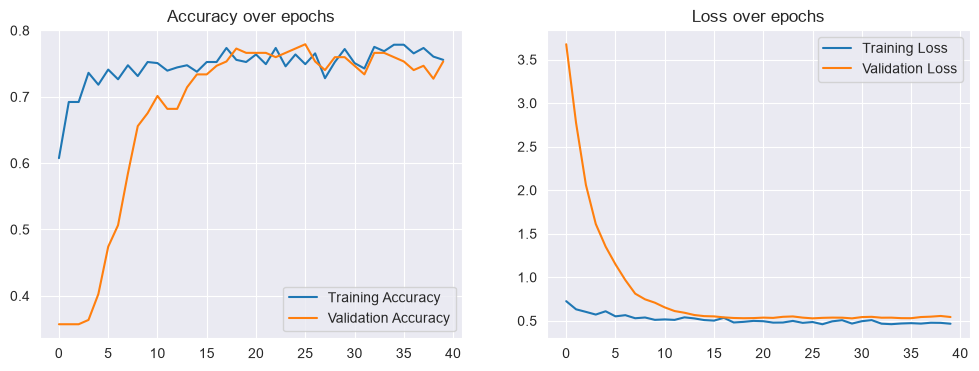

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7597 - loss: 0.5278
Test Accuracy: 0.7597


In [16]:
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Load and clean data
df = pd.read_csv('machine-learning/DiabetesDataset.csv')
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
input_dim = X.shape[1]

# Define a simple neural network
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(input_dim,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, callbacks=[early_stopping], verbose=1)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss over epochs')
plt.show()

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

## Convolutional Neural Networks (CNNs)

### Educational Objectives

- Understand convolution operations for image processing
- Implement pooling layers (max pooling, average pooling)
- Apply CNNs to classification, detection, and segmentation tasks
- Design CNN architectures for various computer vision tasks

### Key Concepts

#### CNN Architecture Components

```{mermaid}
graph LR
    A[Input Image] --> B[Conv2D Layer]
    B --> C[ReLU Activation]
    C --> D[Pooling Layer]
    D --> E[Conv2D Layer]
    E --> F[ReLU Activation]
    F --> G[Pooling Layer]
    G --> H[Flatten]
    H --> I[Dense Layer]
    I --> J[Output Layer]
```

#### Convolution Operation

```{math}
(I * K)(i, j) = \sum_m \sum_n I(i+m, j+n) K(m, n)
```

- **Kernel size**: Typically 3x3, 5x5, 7x7
- **Stride**: Step size of kernel (usually 1)
- **Padding**: 'same' or 'valid'
- **Number of filters**: Determines output depth

#### Pooling Operations

````{grid} 2
:gutter: 2

```{grid-item-card} Max Pooling
Takes maximum value in each window
Preserves most prominent features
Reduces spatial dimensions
```

```{grid-item-card} Average Pooling
Takes average value in each window
Smoother than max pooling
Less sensitive to outliers
```
````

### Practical Example: CNN for Fashion MNIST

```{note}
For image classification:
- Use Conv2D layers to extract spatial features
- Add BatchNormalization for faster convergence
- Use Dropout to prevent overfitting
- End with Dense layers for classification
- Softmax activation for multi-class output
```

In [17]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Load Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Preprocess data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.expand_dims(x_train, -1)  # Shape: (60000, 28, 28, 1)
x_test = np.expand_dims(x_test, -1)    # Shape: (10000, 28, 28, 1)

# Convert labels to one-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Define CNN model
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.5),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')  # 10 classes
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(x_train, y_train, batch_size=128, epochs=30, validation_split=0.2)

# Evaluate
score = model.evaluate(x_test, y_test, verbose=0)
print(f'Test loss: {score[0]:.4f}')
print(f'Test accuracy: {score[1]:.4f}')

Epoch 1/30


/Users/marbetschar/Development/marbetschar/marco.betschart.name/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7201 - loss: 0.7927 - val_accuracy: 0.5803 - val_loss: 1.3395
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8252 - loss: 0.4829 - val_accuracy: 0.8673 - val_loss: 0.3565
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8514 - loss: 0.4158 - val_accuracy: 0.8881 - val_loss: 0.3069
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8632 - loss: 0.3791 - val_accuracy: 0.8914 - val_loss: 0.2920
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8726 - loss: 0.3526 - val_accuracy: 0.8910 - val_loss: 0.2916
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8782 - loss: 0.3383 - val_accuracy: 0.8879 - val_loss: 0.2958
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8833 - loss: 0.3216 - val_accuracy: 0.9041 - val_loss: 0.2614
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8867 - loss: 0.3089 - val_accuracy: 0.909

## Support Vector Machines (SVM)

### Educational Objectives

- Understand the SVM method in detail
- Explain progression from maximal margin classifier to SVM
- Explain the workings of C and γ parameters
- Use SVM successfully on tutorial examples, including parameter grid search
- Write down and explain the primal loss function of SVC
- Apply the kernel trick for non-linearly separable classes
- Understand Mercer Theorem and Representer Theorem

### Key Concepts

#### SVM Evolution

```{mermaid}
graph LR
    A[Maximal Margin<br>Classifier] -->|Allow some<br>misclassification| B[Support Vector<br>Classifier]
    B -->|Non-linear<br>boundaries| C[Support Vector<br>Machine]
```

#### Linear SVM

For linearly separable data, SVM finds the hyperplane that maximizes the margin:

```{math}
\text{Hyperplane: } w^T x + b = 0, \quad \text{Margin: } \frac{2}{\|w\|}
```

Subject to: $y_i (w^T x_i + b) \geq 1$ for all $i$

#### Soft Margin SVM

Allows some misclassifications to handle non-separable data:

```{math}
\text{Minimize: } \frac{1}{2} \|w\|^2 + C \sum_{i=1}^n \xi_i, \quad \text{Subject to: } y_i (w^T x_i + b) \geq 1 - \xi_i, \xi_i \geq 0
```

Where:
- $C$ = Regularization parameter
- $\xi_i$ = Slack variables

#### Kernel Trick

Enables SVM to handle non-linear decision boundaries:

```{math}
K(x_i, x_j) = \phi(x_i)^T \phi(x_j)
```

Common kernel functions:

| Kernel | Function | When to Use |
|--------|----------|-------------|
| **Linear** | $K(x_i, x_j) = x_i^T x_j$ | Linearly separable data |
| **Polynomial** | $K(x_i, x_j) = (\gamma x_i^T x_j + r)^d$ | Polynomial relationships |
| **RBF/Gaussian** | $K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$ | General non-linear problems |

```{prf:theorem} Mercer Theorem
:class: important
A symmetric function $K(x, y)$ can be expressed as an inner product in some high-dimensional feature space if and only if it is positive semi-definite.
```

```{prf:theorem} Representer Theorem
:class: important
The solution to a regularized empirical risk minimization problem can be expressed as a linear combination of kernel functions evaluated at the training points.
```

### Practical Example: SVM with scikit-learn

```{note}
- Always scale your data before using SVM
- C controls trade-off between margin width and misclassification
- gamma controls influence of individual training examples
- Use GridSearchCV for hyperparameter tuning
```

In [20]:
from sklearn.svm import SVC, SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Load and clean data
df = pd.read_csv('machine-learning/DiabetesDataset.csv')
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (critical for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Basic SVM classifier
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_scaled, y_train)

# Predictions
y_pred = svm.predict(X_test_scaled)

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Get support vectors
print(f"Number of support vectors: {svm.n_support_}")

# Hyperparameter tuning
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1], 'kernel': ['linear', 'rbf', 'poly']}
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

Accuracy: 0.7338
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        99
           1       0.65      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154

Number of support vectors: [182 177]
Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best CV score: 0.7720


## Gaussian Processes

### Educational Objectives

- Apply Bayesian learning (Bayes' theorem, Bayesian Regression, Bayes classifier)
- Explain difference between maximum likelihood and Bayesian posterior estimation
- Understand properties of Gaussian distributions (conditional, marginal, product, sum)
- Understand Gaussian Process as a generalization of multivariate Gaussian distribution
- Construct appropriate kernel functions for regression with GP
- Sample functions from a Gaussian process and fit functions to data

### Key Concepts

#### Bayesian Learning

````{grid} 2
:gutter: 2

```{grid-item-card} Maximum Likelihood
**Approach**: Find parameters that maximize likelihood of observed data
**Formula**: $\hat{\theta}_{MLE} = \arg\max_{\theta} P(X | \theta)$
**Property**: Point estimate, no uncertainty quantification
```

```{grid-item-card} Bayesian Posterior
**Approach**: Compute probability distribution over parameters given data
**Formula**: $P(\theta | X) = \frac{P(X | \theta) P(\theta)}{P(X)}$
**Property**: Full distribution, quantifies uncertainty
```
````

#### Gaussian Distribution

```{math}
\mathcal{N}(x | \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
```

Properties:
- **Marginalization**: Any subset of a jointly Gaussian distribution is also Gaussian
- **Conditioning**: Conditioning a Gaussian on some variables results in another Gaussian
- **Sum**: Linear combination of Gaussians is Gaussian

#### Gaussian Process

A Gaussian Process (GP) is a collection of random variables, any finite number of which have a (multivariate) Gaussian distribution.

```{math}
f: X \rightarrow \mathbb{R} \sim \mathcal{GP}(m(x), k(x, x'))
```

Where:
- $m(x)$ = Mean function
- $k(x, x')$ = Covariance function (kernel)

#### Common Kernel Functions

| Kernel | Formula | Properties |
|--------|---------|------------|
| **RBF** | $k(x, x') = \exp\left(-\frac{\|x - x'\|^2}{2\ell^2}\right)$ | Smooth, infinitely differentiable |
| **Linear** | $k(x, x') = x^T x'$ | Linear functions |
| **Polynomial** | $k(x, x') = (x^T x' + c)^d$ | Polynomial functions |

### Practical Example: Gaussian Process Regression

```{note}
Gaussian Processes provide:
- Natural uncertainty quantification through variance
- Non-parametric modeling (can fit complex functions)
- Bayesian approach to regression
- However, they scale as O(n³) with training data size
```

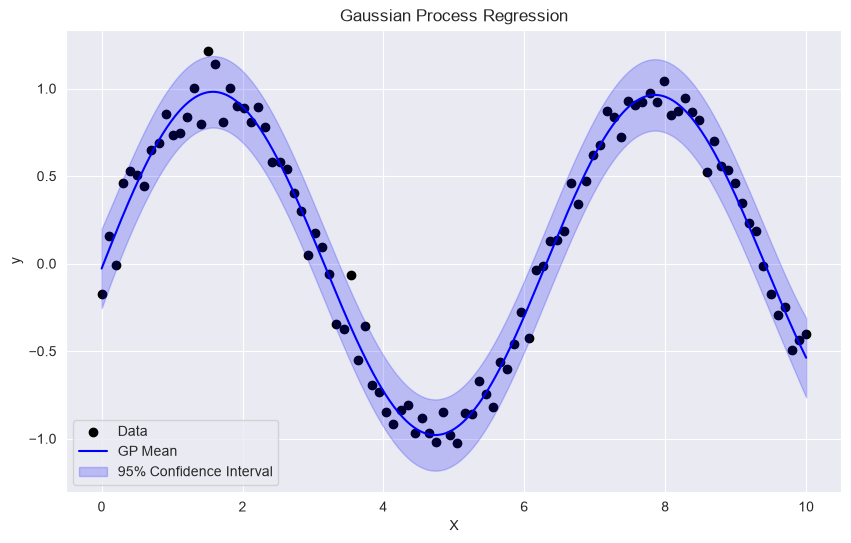

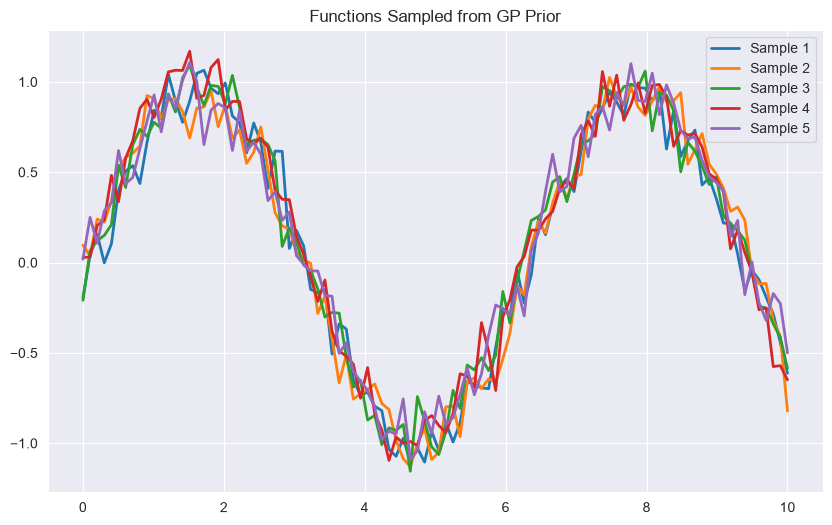

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Generate data
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

# Define kernel
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)

# Create and fit GP
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gp.fit(X, y)

# Make predictions
X_test = np.linspace(0, 10, 500).reshape(-1, 1)
y_pred, y_std = gp.predict(X_test, return_std=True)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, c='k', label='Data')
plt.plot(X_test, y_pred, 'b-', label='GP Mean')
plt.fill_between(X_test.ravel(), y_pred - 1.96 * y_std, y_pred + 1.96 * y_std, alpha=0.2, color='blue', label='95% Confidence Interval')
plt.legend()
plt.title('Gaussian Process Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

# Sample functions from GP prior
X_sample = np.linspace(0, 10, 100).reshape(-1, 1)
y_samples = gp.sample_y(X_sample, n_samples=5)

plt.figure(figsize=(10, 6))
for i in range(5):
    plt.plot(X_sample, y_samples[:, i], lw=2, label=f'Sample {i+1}')
plt.title('Functions Sampled from GP Prior')
plt.legend()
plt.show()

## Dimensionality Reduction

### Educational Objectives

- Understand the curse of dimensionality
- Explain the manifold hypothesis
- Implement Principal Component Analysis (PCA)
- Understand Kernel PCA for non-linear extensions
- Apply manifold learning techniques (MDS, LLE, Isomap, t-SNE)

### Key Concepts

#### Curse of Dimensionality

```{admonition} Problem
:class: warning
As the number of dimensions increases, the data becomes increasingly sparse, and many machine learning algorithms become less effective.
```

#### Manifold Hypothesis

```{admonition} Hypothesis
:class: note
High-dimensional data often lies on or near a low-dimensional manifold.
```

```{note}
- PCA is linear and fast, good for initial exploration
- t-SNE is excellent for visualization but doesn't preserve global structure well
- Use MDS when you want to preserve distances
- Manifold methods are powerful but can be computationally expensive
```

#### Principal Component Analysis (PCA)

PCA finds orthogonal directions (principal components) that maximize variance. Steps:

1. Center the data: $X_{centered} = X - \bar{X}$
2. Compute covariance matrix: $\Sigma = \frac{1}{n} X_{centered}^T X_{centered}$
3. Eigendecomposition: $\Sigma = V \Lambda V^T$
4. Select top $k$ eigenvectors

### Practical Example: PCA for Visualization

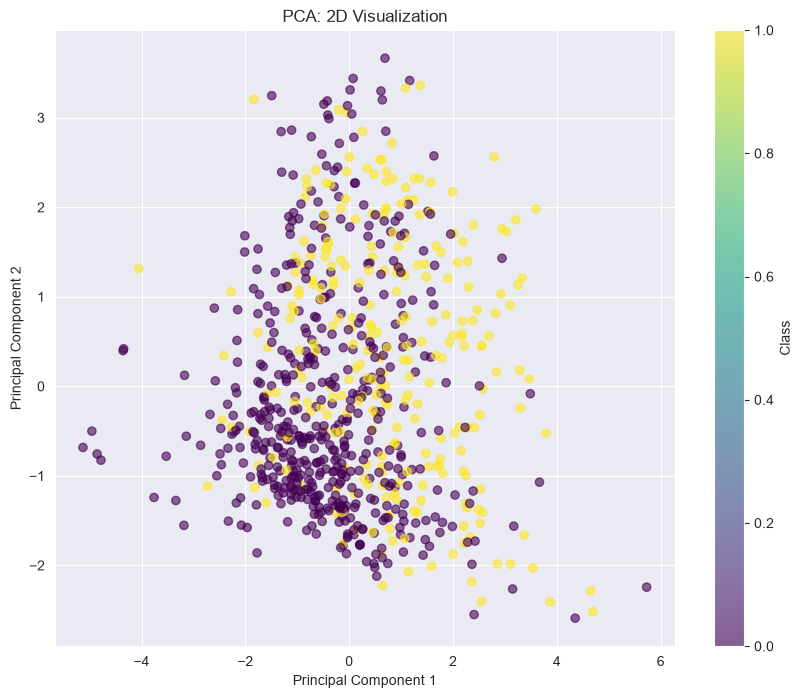

Explained variance ratio: [0.26179749 0.21640127]
Total explained variance: 0.4782


In [4]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load and clean data
df = pd.read_csv('machine-learning/DiabetesDataset.csv')
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.colorbar(label='Class')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: 2D Visualization')
plt.show()

# Explained variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {sum(pca.explained_variance_ratio_):.4f}")

#### Kernel PCA

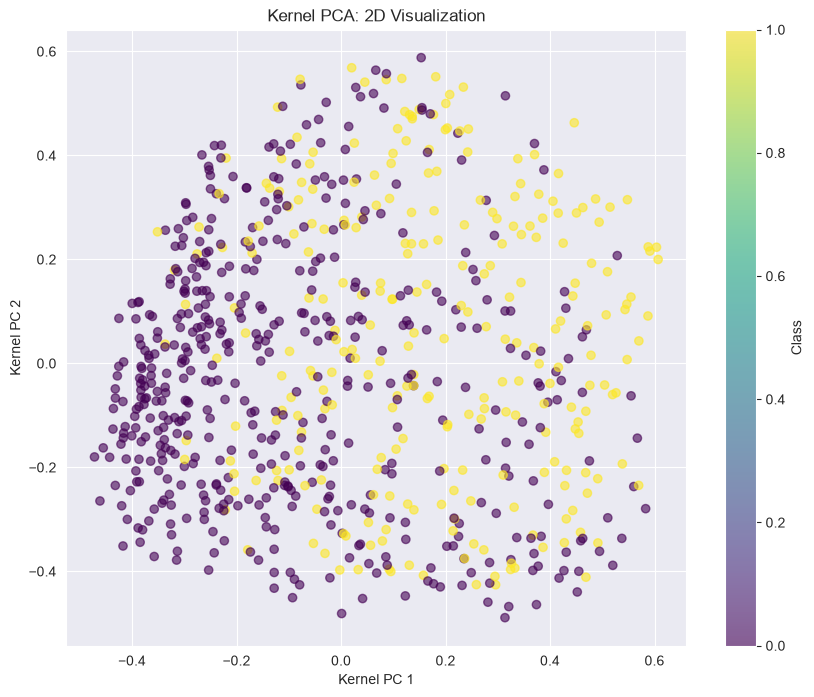

In [5]:
from sklearn.decomposition import KernelPCA

# Kernel PCA with RBF kernel
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.04, fit_inverse_transform=True)
X_kpca = kpca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.colorbar(label='Class')
plt.xlabel('Kernel PC 1')
plt.ylabel('Kernel PC 2')
plt.title('Kernel PCA: 2D Visualization')
plt.show()

#### Manifold Learning Techniques

````{grid} 2
:gutter: 2

```{grid-item-card} MDS
- Preserves pairwise distances
- Linear technique
- Good for visualization
```

```{grid-item-card} t-SNE
- Preserves local structure
- Non-linear technique
- Excellent for visualization
- Computationally expensive
```
````

````{grid} 2
:gutter: 2

```{grid-item-card} LLE
- Preserves local linear relationships
- Non-linear technique
- Good for manifold learning
```

```{grid-item-card} Isomap
- Preserves geodesic distances
- Non-linear technique
- Uses neighborhood graph
```
````

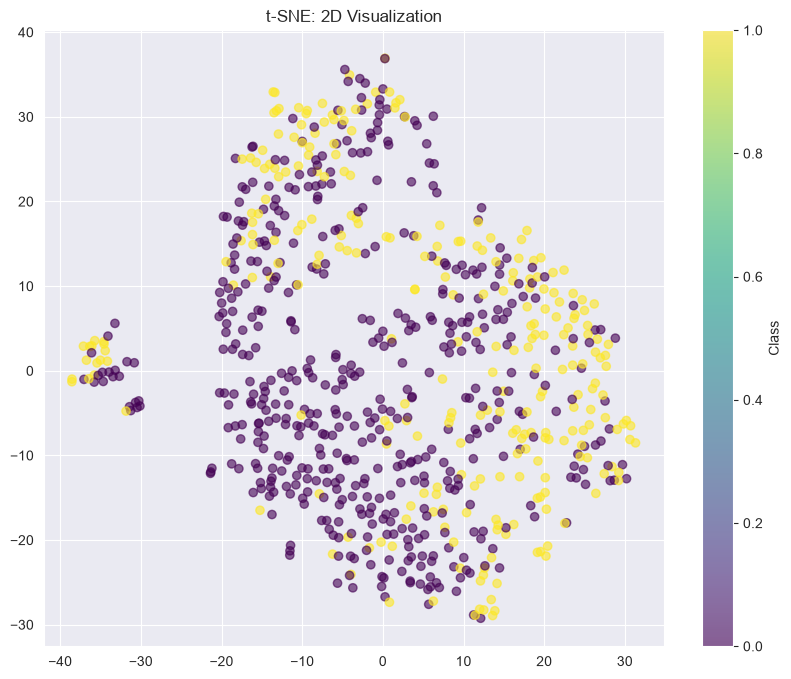

In [7]:
from sklearn.manifold import TSNE

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled[:1000])  # Use subset for speed

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y[:1000], cmap='viridis', alpha=0.6)
plt.colorbar(label='Class')
plt.title('t-SNE: 2D Visualization')
plt.show()

## Cluster Analysis

### Educational Objectives

- Understand different clustering paradigms
- Implement and interpret hierarchical clustering
- Use the elbow method to determine optimal number of clusters
- Apply partitioning methods like k-Means
- Understand density-based clustering (DBSCAN)
- Evaluate clustering results

### Key Concepts

#### Types of Clustering

````{grid} 3
:gutter: 1

```{grid-item-card} Partitioning
- **k-Means**: Partitions data into k clusters
- **k-Medoids**: Uses actual data points as centers
- **Fuzzy c-Means**: Soft clustering (probabilistic)
```

```{grid-item-card} Hierarchical
- **Agglomerative**: Bottom-up
- **Divisive**: Top-down
- **Dendrogram**: Visual representation
```

```{grid-item-card} Density-Based
- **DBSCAN**: Density-based spatial clustering
- **OPTICS**: Similar to DBSCAN but more robust
- **HDBSCAN**: Hierarchical DBSCAN
```
````

#### k-Means Algorithm

1. Initialize k cluster centers randomly
2. Assign each point to nearest cluster center
3. Recalculate cluster centers as mean of assigned points
4. Repeat steps 2-3 until convergence

```{math}
\text{Objective: Minimize WCSS} = \sum_{i=1}^k \sum_{x \in C_i} \|x - \mu_i\|^2
```

### Practical Example: k-Means Clustering

```{note}
- k-Means: Fast, scales well, but requires specifying k and assumes spherical clusters
- Hierarchical: No need to specify k, but computationally expensive (O(n³))
- DBSCAN: Can find arbitrary shaped clusters, robust to outliers, but sensitive to parameters
```

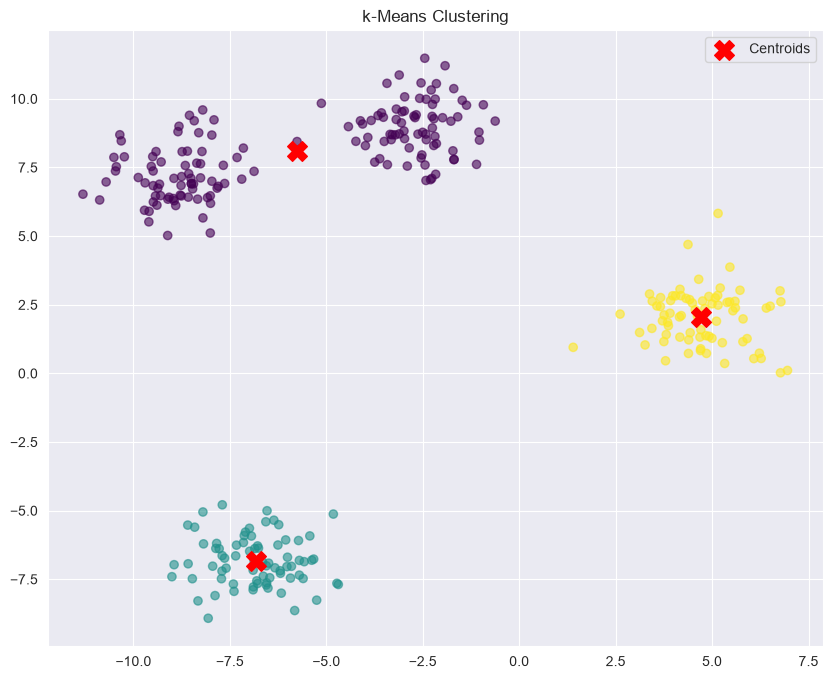

Silhouette Score: 0.7569
Davies-Bouldin Score: 0.3560


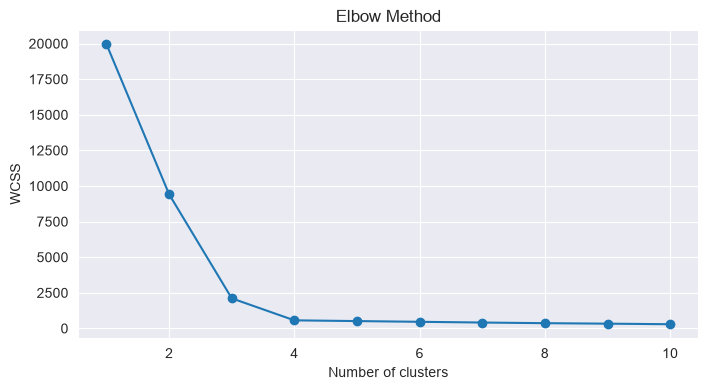

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

# k-Means clustering
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X)

# Plot clusters
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.legend()
plt.title('k-Means Clustering')
plt.show()

# Evaluate clustering
print(f"Silhouette Score: {silhouette_score(X, clusters):.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_score(X, clusters):.4f}")

# Elbow method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

#### Hierarchical Clustering Example

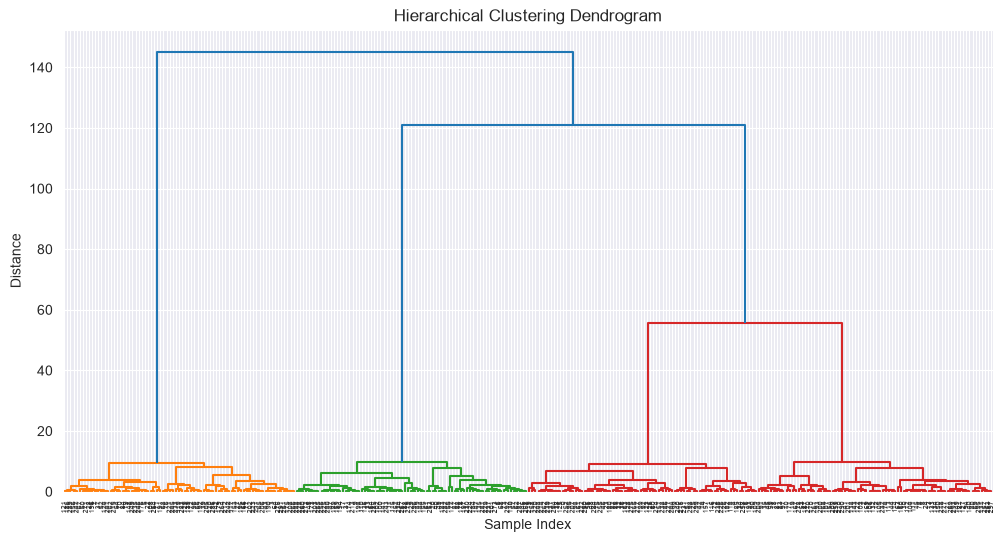

In [18]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

# Perform hierarchical clustering
Z = linkage(X, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=12)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# Cut dendrogram
clusters = fcluster(Z, t=10, criterion='distance')

#### DBSCAN Example

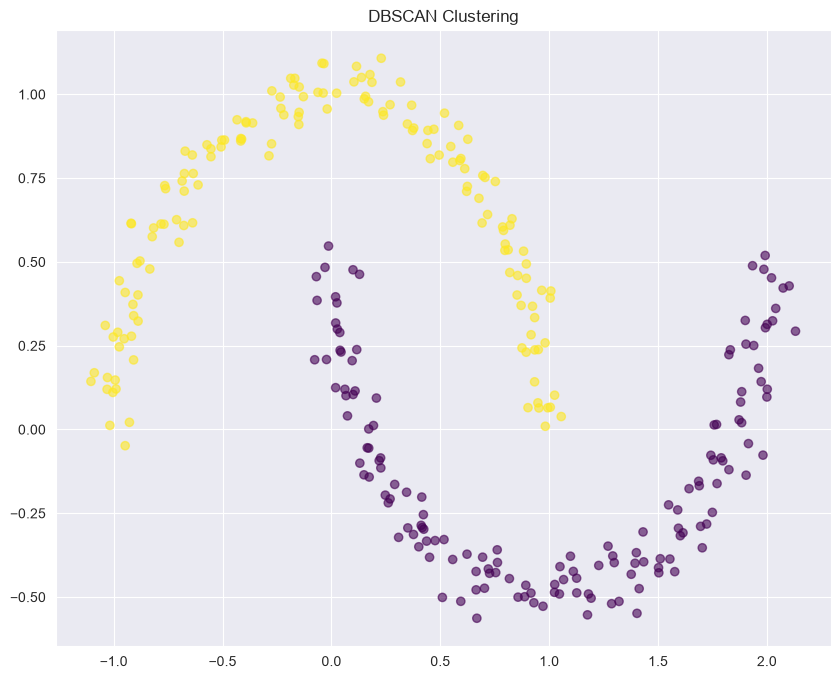

Number of clusters: 2
Number of noise points: 0


In [26]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

# DBSCAN
dbscan = DBSCAN(eps=0.25, min_samples=5, metric='euclidean')
clusters = dbscan.fit_predict(X)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title('DBSCAN Clustering')
plt.show()

# Count clusters and noise
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

## Gaussian Mixture Models & Expectation-Maximization

### Educational Objectives

- Understand Gaussian Mixture Models (GMMs)
- Implement the Expectation-Maximization (EM) algorithm
- Understand soft clustering vs. hard clustering
- Apply GMMs to real-world data
- Understand the relationship between GMMs and k-Means

### Key Concepts

#### Gaussian Mixture Model

A probabilistic model that assumes data is generated from a mixture of several Gaussian distributions:

```{math}
P(x) = \sum_{k=1}^K \pi_k \mathcal{N}(x | \mu_k, \Sigma_k)
```

Where:
- $\pi_k$ = Mixing coefficient, $\sum \pi_k = 1$
- $\mu_k$ = Mean of component k
- $\Sigma_k$ = Covariance matrix of component k

#### Expectation-Maximization (EM) Algorithm

1. **E-step (Expectation)**: Compute posterior probabilities (responsibilities)
2. **M-step (Maximization)**: Update parameters using current responsibilities
3. Repeat until convergence

```{math}
\text{E-step: } \gamma_{nk} = \frac{\pi_k \mathcal{N}(x_n | \mu_k, \Sigma_k)}{\sum_{j=1}^K \pi_j \mathcal{N}(x_n | \mu_j, \Sigma_j)}
```

#### GMM vs. k-Means

| Aspect | GMM | k-Means |
|--------|-----|---------|
| **Clustering** | Soft (probabilistic) | Hard (deterministic) |
| **Cluster Shape** | Elliptical | Spherical |
| **Covariance** | Can be different | Same (identity) |
| **Probabilistic** | Yes | No |

### Practical Example: GMM with scikit-learn

```{note}
- GMMs can model more complex cluster shapes than k-Means
- Use BIC or AIC for model selection (lower is better)
- GMMs can be slow for large datasets
- The EM algorithm is guaranteed to converge to a local optimum
```

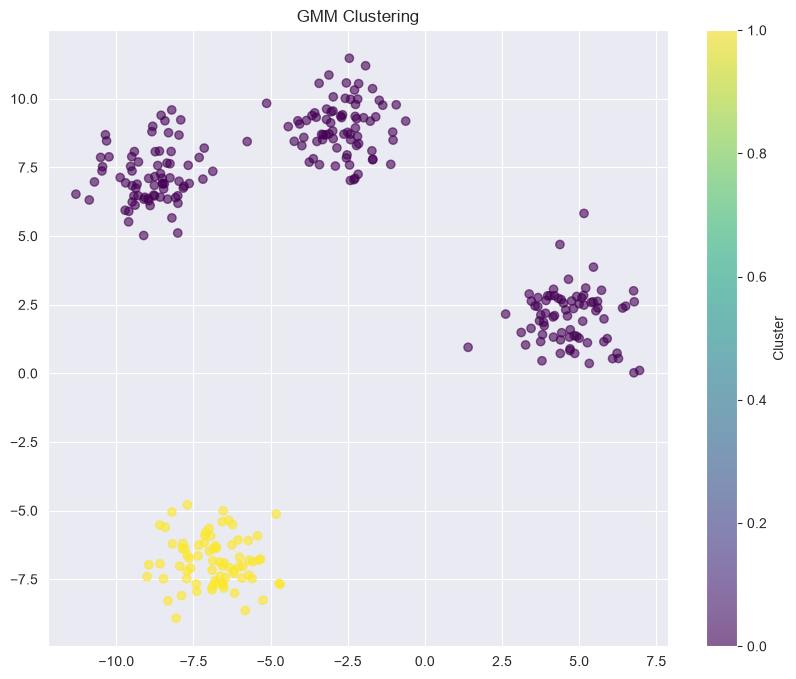

Means:
[[-2.26099844  6.07059032]
 [-6.83235214 -6.83045757]]
Covariances:
[[[ 31.61453403 -12.1886063 ]
  [-12.1886063    9.63288295]]

 [[  1.011053    -0.06122604]
  [ -0.06122604   0.79622858]]]
Weights:
[0.75000001 0.24999999]
AIC: 3181.6956036449124, BIC: 3222.4372108661305


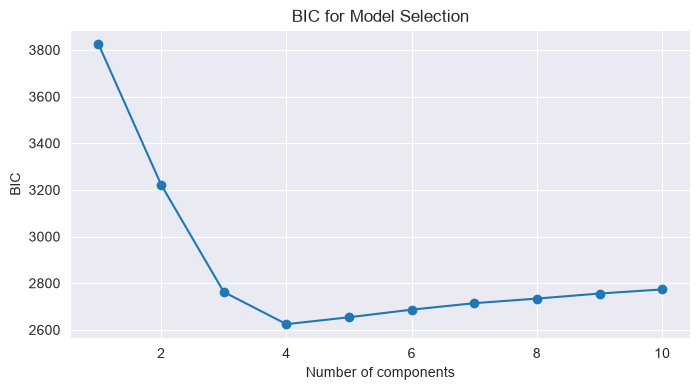

In [35]:
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

# Fit GMM
n_components = 2
gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
gmm.fit(X)

# Predict cluster assignments (hard clustering)
clusters = gmm.predict(X)

# Get probabilities (soft clustering)
probabilities = gmm.predict_proba(X)

# Plot clusters with uncertainty
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title('GMM Clustering')
plt.colorbar(scatter, label='Cluster')
plt.show()

# Print model parameters
print(f"Means:\n{gmm.means_}")
print(f"Covariances:\n{gmm.covariances_}")
print(f"Weights:\n{gmm.weights_}")

# Calculate AIC and BIC
aic = gmm.aic(X)
bic = gmm.bic(X)
print(f"AIC: {aic}, BIC: {bic}")

# Find optimal number of components using BIC
n_components_range = range(1, 11)
bic_scores = []
for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X)
    bic_scores.append(gmm.bic(X))

plt.figure(figsize=(8, 4))
plt.plot(n_components_range, bic_scores, marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC')
plt.title('BIC for Model Selection')
plt.show()

## Reinforcement Learning

### Educational Objectives

- Define finite Markov Decision Process (MDP) and Markov Reward Process (MRP)
- Understand value iteration and Q-learning algorithms
- Explain the difference between on-policy and off-policy learning
- Explain the difference between value iteration and policy iteration
- Understand the trade-off between exploitation and exploration

### Key Concepts

#### Markov Decision Process (MDP)

A framework for modeling decision-making situations:

```{math}
\text{MDP} = (S, A, P, R, \gamma)
```

Where:
- $S$ = Set of states
- $A$ = Set of actions
- $P(s'|s,a)$ = Transition probability
- $R(s,a,s')$ = Reward function
- $\gamma$ = Discount factor ($0 \leq \gamma \leq 1$)

#### Markov Property

```{math}
P(s_{t+1} | s_t, a_t, s_{t-1}, a_{t-1}, ...) = P(s_{t+1} | s_t, a_t)
```

#### Value Functions

```{math}
V^\pi(s) = \mathbb{E}_\pi \left[ \sum_{k=0}^\infty \gamma^k R_{t+k+1} \mid S_t = s \right]\\
Q^\pi(s,a) = \mathbb{E}_\pi \left[ \sum_{k=0}^\infty \gamma^k R_{t+k+1} \mid S_t = s, A_t = a \right]
```

#### Bellman Equation

```{math}
V^\pi(s) = \mathbb{E}_\pi \left[ R_{t+1} + \gamma V^\pi(S_{t+1}) \mid S_t = s \right]\\
Q^\pi(s,a) = \mathbb{E}_\pi \left[ R_{t+1} + \gamma Q^\pi(S_{t+1}, A_{t+1}) \mid S_t = s, A_t = a \right]
```

#### Optimal Policy

```{math}
\pi^*(s) = \arg\max_a Q^*(s,a), \quad \text{where } Q^*(s,a) = \max_\pi Q^\pi(s,a)
```

#### Dynamic Programming Methods

##### Value Iteration

```{math}
V_{k+1}(s) = \max_a \mathbb{E} \left[ R_{t+1} + \gamma V_k(S_{t+1}) \mid S_t = s, A_t = a \right]
```

##### Policy Iteration

1. **Policy Evaluation**: Compute $V^\pi$ for current policy
2. **Policy Improvement**: Update policy to be greedy with respect to $V^\pi$

#### Temporal Difference Learning

```{math}
\text{TD(0): } V(S_t) \leftarrow V(S_t) + \alpha \left[ R_{t+1} + \gamma V(S_{t+1}) - V(S_t) \right]
```

#### Q-Learning

```{math}
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t) \right]
```

#### Exploration vs. Exploitation

````{grid} 2
:gutter: 2

```{grid-item-card} Exploration
- Try different actions to discover better strategies
- Needed to find optimal policy
- Can lead to suboptimal short-term rewards
```

```{grid-item-card} Exploitation
- Use known best action to maximize immediate reward
- Can miss better long-term strategies
- Suboptimal in the long run if overused
```
````

Common exploration strategies:
- **ε-greedy**: Choose random action with probability ε
- **Decaying ε-greedy**: ε decreases over time
- **Upper Confidence Bound (UCB)**: Balance exploration and exploitation
- **Thompson Sampling**: Probabilistic approach based on uncertainty

#### On-Policy vs. Off-Policy

| Aspect | On-Policy | Off-Policy |
|--------|-----------|-------------|
| **Definition** | Learns about and improves the same policy | Learns about one policy while following another |
| **Example** | SARSA | Q-Learning |
| **Advantage** | Directly learns the policy being followed | Can learn optimal policy while following exploratory policy |
| **Disadvantage** | Must balance exploration/exploitation | More complex, can be unstable |

### Practical Example: Q-Learning for Frozen Lake

```{note}
- Q-Learning is an off-policy algorithm
- It learns the optimal policy regardless of the exploration strategy
- The ε-greedy strategy ensures exploration
- The learning rate (α) and discount factor (γ) are crucial hyperparameters
```

In [24]:
import gym
import numpy as np
np.bool8 = np.bool # Fix for AttributeError: module 'numpy' has no attribute 'bool8'

# Create FrozenLake environment
env = gym.make('FrozenLake-v1', is_slippery=False)

# Initialize Q-table
Q = np.zeros((env.observation_space.n, env.action_space.n))

# Hyperparameters
alpha = 0.8  # Learning rate
gamma = 0.95  # Discount factor
epsilon = 0.1  # Exploration rate
episodes = 10000

# Q-learning algorithm
for episode in range(episodes):
    state = env.reset()[0]
    done = False
    truncated = False

    while not done and not truncated:
        # Epsilon-greedy action selection
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()  # Explore
        else:
            action = np.argmax(Q[state, :])  # Exploit

        # Take action
        next_state, reward, done, truncated, info = env.step(action)

        # Q-learning update
        best_next_action = np.argmax(Q[next_state, :])
        td_target = reward + gamma * Q[next_state, best_next_action]
        td_error = td_target - Q[state, action]
        Q[state, action] += alpha * td_error

        # Update state
        state = next_state

# Test the learned policy
state = env.reset()[0]
done = False
truncated = False

while not done and not truncated:
    action = np.argmax(Q[state, :])
    state, reward, done, truncated, info = env.step(action)
    if done or truncated:
        print(f"Final reward: {reward}")
        break
env.close()

Final reward: 0.0


## Ensemble Methods

### Educational Objectives

- Understand ensemble learning principles
- Implement bagging methods (e.g., Random Forest)
- Implement boosting methods (e.g., AdaBoost, Gradient Boosting)
- Understand the bias-variance tradeoff in ensemble methods
- Apply ensemble methods to real-world problems

### Key Concepts

#### Ensemble Learning

Combining multiple models to improve performance:

```{mermaid}
graph LR
    A[Model 1] --> C[Combine]
    B[Model 2] --> C
    D[Model 3] --> C
    C --> E[Final Prediction]
```

#### Types of Ensembles

````{grid} 2
:gutter: 2

```{grid-item-card} Bagging (Bootstrap Aggregating)
- **Principle**: Reduce variance by averaging multiple models
- **Method**: Train models on different bootstrap samples
- **Example**: Random Forest
- **Effect**: Reduces variance, prevents overfitting
```

```{grid-item-card} Boosting
- **Principle**: Reduce bias by sequentially correcting errors
- **Method**: Train models sequentially, each focusing on previous errors
- **Examples**: AdaBoost, Gradient Boosting, XGBoost
- **Effect**: Reduces bias, improves accuracy
```
````

#### Gini Impurity

Gini Impurity is a measure of **node purity** used in decision trees (CART algorithm). It quantifies the probability of misclassifying a randomly selected sample in a node if it were labeled according to the distribution of classes in the node.

For a node with $K$ classes, where $p_i$ is the proportion of class $i$:

$$
\text{Gini} = 1 - \sum_{i=1}^{K} p_i^2
$$

- **Range**: 0 (perfectly pure) to $1 - \frac{1}{K}$ (maximally impure)
- **Interpretation**: Lower values indicate higher purity

In [7]:
def gini_impurity(counts):
    total = sum(counts)

    if total == 0:
        return 0.0

    probabilities = [c / total for c in counts]
    return 1 - sum(p**2 for p in probabilities)


def gini_split(*children):
    """
    Compute the weighted Gini impurity of an arbitrary split.

    Parameters
    ----------
    *children : iterable of class counts
        Examples:
            [7, 0]
            [10, 4]
            [3, 2, 5]   # multiclass

    Returns
    -------
    float
        Weighted Gini impurity of the split.
    """
    total_samples = sum(sum(child) for child in children)

    if total_samples == 0:
        return 0.0

    return sum(
        (sum(child) / total_samples) * gini_impurity(child)
        for child in children
    )

print(gini_split([7, 0], [9, 4]))

0.276923076923077


#### Random Forest

An ensemble of decision trees trained on bootstrap samples with feature subsampling:

1. Create bootstrap samples (with replacement)
2. For each sample, train a decision tree on a random subset of features
3. Average predictions from all trees

```{math}
\text{Feature subsampling: } m \approx \sqrt{d} \text{ for classification, } m \approx d/3 \text{ for regression}
```

#### Boosting Methods

````{grid} 2
:gutter: 2

```{grid-item-card} AdaBoost
- **Idea**: Give more weight to misclassified samples
- **Algorithm**: Sequentially train models, reweighting data
- **Weight Update**: Increase weights for misclassified samples
```

```{grid-item-card} Gradient Boosting
- **Idea**: Fit new models to residual errors
- **Algorithm**: Each new model corrects errors of previous ensemble
- **Loss**: Minimizes loss function (e.g., MSE, log-loss)
```
````

### Practical Example: Random Forest

```{note}
- Random Forest: Parallel training, robust to outliers, good for high-dimensional data
- Gradient Boosting: Sequential training, often better accuracy but slower to train
- AdaBoost: Sensitive to noisy data and outliers
- XGBoost, LightGBM, CatBoost: Advanced implementations with additional features
```

Random Forest Accuracy: 0.7208


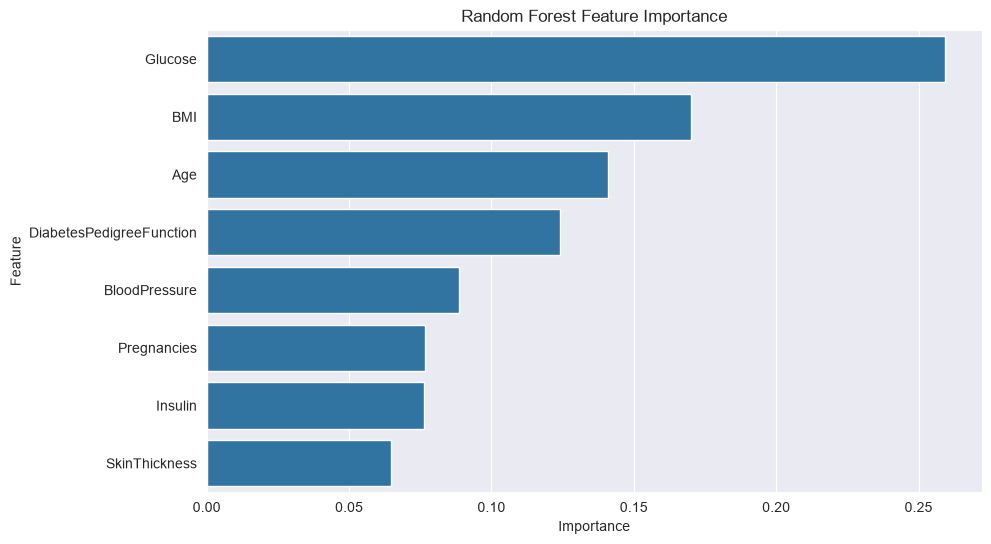

In [45]:
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Load and clean data
df = pd.read_csv('machine-learning/DiabetesDataset.csv')
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

# Feature importance
importances = rf.feature_importances_
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Random Forest Feature Importance')
plt.show()

#### Gradient Boosting Example

Gradient Boosting Accuracy: 0.7468


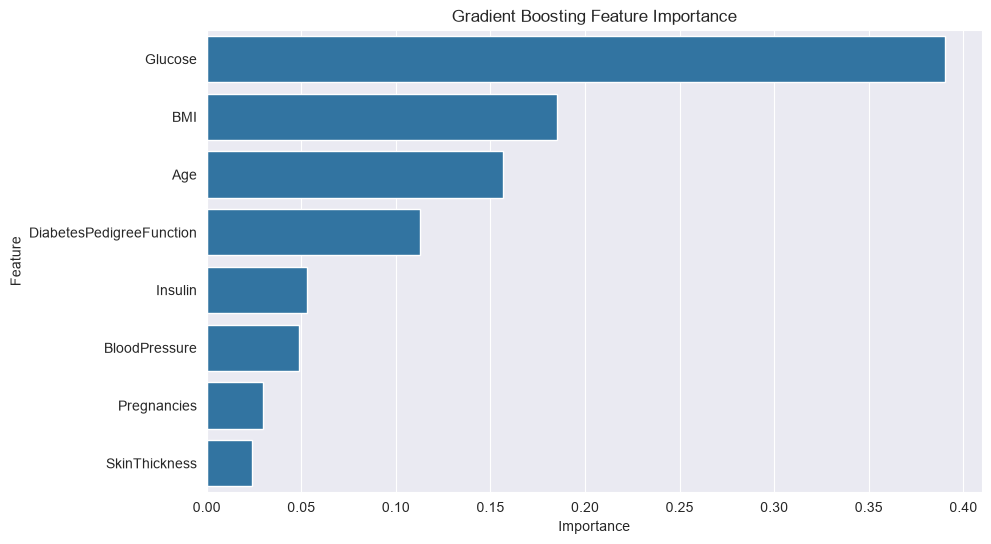

In [46]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")

# Plot feature importance
feature_importance_gb = pd.DataFrame({'Feature': X.columns, 'Importance': gb.feature_importances_}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_gb)
plt.title('Gradient Boosting Feature Importance')
plt.show()

#### AdaBoost Example

In [47]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}")

AdaBoost Accuracy: 0.7403


## Generative AI and Wrap-Up

### Educational Objectives

- Understand the landscape of generative AI
- Explain different generative modeling approaches
- Understand applications and limitations of generative models
- Reflect on the future of machine learning
- Integrate knowledge from all course topics

### Key Concepts

#### Generative AI Overview

Generative AI models learn to generate new data that resembles the training data:

````{grid} 3
:gutter: 1

```{grid-item-card} Generative Adversarial Networks (GANs)
- **Idea**: Two neural networks compete (generator vs. discriminator)
- **Training**: Generator tries to fool discriminator
- **Applications**: Image generation, style transfer
```

```{grid-item-card} Variational Autoencoders (VAEs)
- **Idea**: Learn probability distribution of data
- **Training**: Maximize likelihood of data
- **Applications**: Image generation, anomaly detection
```

```{grid-item-card} Large Language Models (LLMs)
- **Idea**: Predict next token in sequence
- **Training**: Self-supervised on vast text data
- **Applications**: Text generation, translation, coding
```
````

#### Generative Model Types

| Model | Approach | Training | Applications |
|-------|----------|----------|-------------|
| **GAN** | Adversarial | Minimax game | Images, audio |
| **VAE** | Probabilistic | Maximum likelihood | Images, data generation |
| **Autoregressive** | Sequential | Next token prediction | Text, audio, video |
| **Diffusion** | Iterative denoising | Noise removal | Images, audio |

#### Trends

- **Scale**: Models continue to grow in size and capability
- **Efficiency**: More efficient architectures and training methods
- **Multimodality**: Models that understand multiple data types
- **Alignment**: Ensuring models behave as intended (safety, ethics)
- **Interpretability**: Understanding model decisions
- **Automation**: AutoML and hyperparameter optimization
